Beautiful METAR photo

# METAR Local Statistics Notebook        
        
This chapter walks you through the request and access of local **METeorological Aerodrome Report (METAR)** data from **Dynamical.org**, a climatological analysis using your station's full data record, and *something else*. This notebook will leave you with organized plots and a greater understanding of your region's climatological trends. 

---

### Purpose
To provide hands-on experience in requesting and working with near real-time METAR data from Dynamical.org.

### Audience
Users with at least **5 GB of memory [TEST THIS!!!]** in their computing environment.      
No programming experience is necessary to run the notebook, but a **basic knowledge of Python** (especially pandas and matplotlib) will help you apply these skills!

### Expected Outcome
By the end of this chapter, you will have produced numerous **climatological plots** that analyze all available METAR records from within 20 miles of your requested location. *If you wish to continue working with near real-time METAR data beyond this notebook, there are three bonus challenges at the end of the notebook that encourage the user to further apply their skills.* **[GOTTA DO THIS]**         

### Estimated Time [CHANGE THESE]
- **15 minutes** — Run the notebook and review the code.  
- **30 minutes** — Build enough familiarity to reproduce the workflow independently and begin to tackle the bonus challenges.
- **2 hours** - Complete all bonus steps and begin to integrate these concepts into your own workflow. 


---

## 📦 Imports

In [1]:
import duckdb
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
import requests
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

---

## About ASOS
Words about ASOS.

## About Dynamical.org
Words about Dynamical.

:::{hint}
Hint about using dynamical to perform different queries:

---

## 📌 Location query
This section of the notebook uses the Python package 'geopy' to take in a user-requested geographic location and return a corresonding lat/lon point. Then, the code requests all lat/lon points associated with an ASOS station from the database hosted by Dynamical, locates the closest station (within 20 miles), and procures all historical ASOS observations for that site. 

In [2]:
# Select the geographic location of interest using geopy
try:
    location_query = input("Enter a location (city, address, etc.) [default: JFK Airport, NY]: ").strip()
    if not location_query:
        location_query = "JFK Airport, New York"
except:
    location_query = "JFK Airport, New York"

geolocator = Nominatim(user_agent="asos_finder")
requested_location = geolocator.geocode(location_query)
print(f"Location: {requested_location.address}")

Enter a location (city, address, etc.) [default: JFK Airport, NY]:  Manhattan, KS


Location: Manhattan, Riley County, Kansas, United States


In [3]:
# Retrieve station data to perform the lat/lon query
url = "https://data.source.coop/dynamical/asos-parquet/year=2026/data.parquet"
stations_df = duckdb.execute("""
    SELECT DISTINCT station as stid, name as sname, latitude as lat, longitude as lon
    FROM read_parquet($1)
    WHERE longitude IS NOT NULL AND latitude IS NOT NULL
""", [url]).fetchdf()

# Determine which ASOS station is closest to the requested point
user_coords = (requested_location.latitude, requested_location.longitude)
stations_df['distance_miles'] = stations_df.apply(
    lambda row: geodesic(user_coords, (row['lat'], row['lon'])).miles, axis=1
)
nearby_stations = stations_df[stations_df['distance_miles'] <= 20].sort_values('distance_miles')
nearest_station = nearby_stations.iloc[0]

# Print the results of the query
print(f"Nearest station: {nearest_station.stid}, {nearest_station.sname}")
print(f"Distance: {nearest_station['distance_miles']:.1f} miles")

Nearest station: MHK, MANHATTAN
Distance: 6.6 miles


In [4]:
# Load all data from the nearest station
base = "https://data.source.coop/dynamical/asos-parquet"
urls = [f"{base}/year={y}/data.parquet" for y in range(1940, datetime.now().year + 1)]

location_df = duckdb.execute("""
    SELECT valid as datetime, station, name, longitude, latitude, tmpf as temp_f,
    dwpf as dewpoint_f, relh as relative_humidity, drct as wind_dir, sknt as wspd_kt,
    gust as gust_kt, mslp as msl_pressure, vsby as visibility, p01i as precip_inches
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2
    ORDER BY valid
""", [urls, nearest_station.stid]).fetchdf()

location_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,datetime,station,name,longitude,latitude,temp_f,dewpoint_f,relative_humidity,wind_dir,wspd_kt,gust_kt,msl_pressure,visibility,precip_inches
0,1973-01-01 00:00:00+00:00,MHK,MANHATTAN,-96.6778,39.1353,26.6,12.2,54.03,270.0,5.0,NaN,NaN,7.0,NaN
1,1973-01-01 01:00:00+00:00,MHK,MANHATTAN,-96.6778,39.1353,24.8,15.8,68.18,0.0,0.0,NaN,NaN,7.0,NaN
2,1973-01-01 02:00:00+00:00,MHK,MANHATTAN,-96.6778,39.1353,21.2,12.2,67.73,0.0,0.0,NaN,NaN,7.0,NaN
3,1973-01-01 03:00:00+00:00,MHK,MANHATTAN,-96.6778,39.1353,21.2,12.2,67.73,0.0,0.0,NaN,NaN,7.0,NaN
4,1973-01-01 04:00:00+00:00,MHK,MANHATTAN,-96.6778,39.1353,21.2,12.2,67.73,0.0,0.0,NaN,NaN,7.0,NaN


## Climatological Analysis
The analysis component of the notebook uses the available historical ASOS observations to tell a story about meteorological-informed patterns: the growing season, annual precipitation patterns, cloudiness, extreme heat, and more.

In [5]:
# Add some metadata to the columns of the dataframe
location_df['datetime'] = location_df['datetime'].dt.round('h')
location_df['date'] = location_df['datetime'].dt.date
location_df['year'] = location_df['datetime'].dt.year
location_df['doy'] = location_df['datetime'].dt.dayofyear
location_df['hour'] = location_df['datetime'].dt.hour

daily_stats = location_df.groupby('date').agg(
    tmin=('temp_f', 'min'),
    tmax=('temp_f', 'max'),
    vismean=('visibility', 'mean'),
    preciptotal=('precip_inches', 'sum'),
    dewmean=('dewpoint_f', 'max'),
    gustmax=('gust_kt','max'),
    mslpmin=('msl_pressure', 'min'),
    doy=('doy', 'first'),
    year=('year', 'first')
).reset_index()

### Growing Season

In [6]:
last_spring_freeze = (
    daily_stats[(daily_stats['doy'] < 183) & (daily_stats['tmin'] < 32)]
    .groupby('year')['doy']
    .max()
    .rename('last_spring_freeze'))
first_fall_freeze = (
    daily_stats[(daily_stats['doy'] > 183) & (daily_stats['tmin'] < 32)]
    .groupby('year')['doy']
    .min()
    .rename('first_fall_freeze'))
freeze_indices = (pd.concat([last_spring_freeze, first_fall_freeze], axis=1)).dropna()

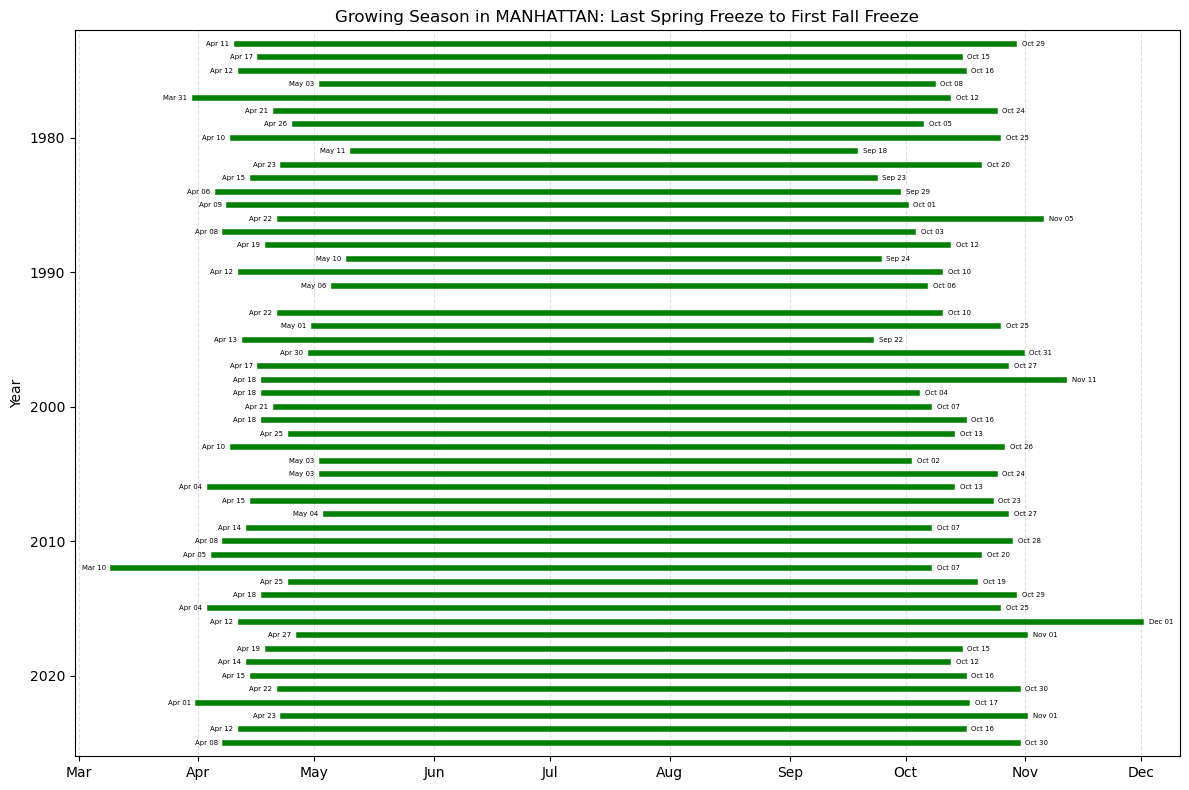

In [7]:
def doy_to_ref_date_jan(year, doy):
    real_date = date(int(year), 1, 1) + pd.Timedelta(days=int(doy) - 1)
    return date(2016, real_date.month, real_date.day)

freeze_indices['fall_ref_jan']   = [doy_to_ref_date_jan(y, d) for y, d in 
                                    zip(freeze_indices.index, freeze_indices['first_fall_freeze'])
                                   ]
freeze_indices['spring_ref_jan'] = [doy_to_ref_date_jan(y, d) for y, d in 
                                    zip(freeze_indices.index, freeze_indices['last_spring_freeze'])
                                   ]

fig, ax = plt.subplots(figsize=(12, 8))
years = freeze_indices.index.tolist()

for year in years:
    row = freeze_indices.loc[year]
    ax.plot(
        [row['spring_ref_jan'], row['fall_ref_jan']], [year, year],
        color='green', linewidth=4, alpha=1)
    ax.text(row['spring_ref_jan'] - pd.Timedelta(days=2), year,
            pd.Timestamp(row['spring_ref_jan']).strftime('%b %d'),
            ha='right', va='center', fontsize=5, color='black')
    ax.text(row['fall_ref_jan'] + pd.Timedelta(days=2), year,
            pd.Timestamp(row['fall_ref_jan']).strftime('%b %d'),
            ha='left', va='center', fontsize=5, color='black')

ax.set_xlim(
    freeze_indices['spring_ref_jan'].min() - pd.Timedelta(days=10),
    freeze_indices['fall_ref_jan'].max() + pd.Timedelta(days=10)
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylim(max(years) + 1, min(years) - 1)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.set_ylabel('Year')
ax.set_title(f'Growing Season in {location_df.name[0]}: Last Spring Freeze to First Fall Freeze')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Hot Days

In [8]:
current_year = pd.Timestamp.now().year
hot_days_90f = daily_stats[(daily_stats['tmax'] >= 90) & (daily_stats['year'] < current_year)]
hot_days_100f = daily_stats[(daily_stats['tmax'] >= 100) & (daily_stats['year'] < current_year)]

hot_days_annual_90 = hot_days_90f.groupby('year').size()
hot_days_annual_100 = hot_days_100f.groupby('year').size()

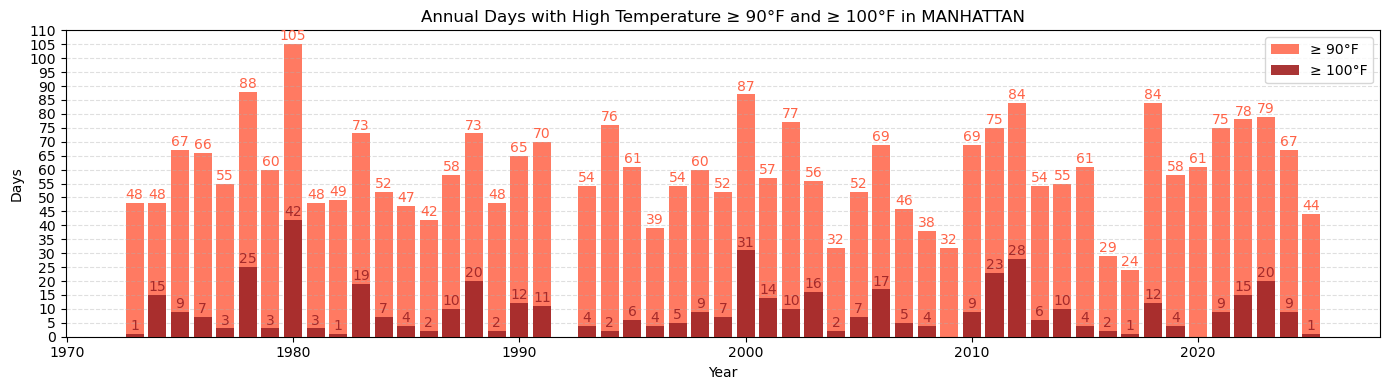

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(hot_days_annual_90.index, hot_days_annual_90.values, color='tomato', width=0.8, alpha=0.85, label='≥ 90°F')
ax.bar(hot_days_annual_100.index, hot_days_annual_100.values, color='brown', width=0.8, alpha=0.95, label='≥ 100°F', zorder=3)

for year, val in hot_days_annual_90.items():
    ax.text(year, val + 0.3, str(val), ha='center', va='bottom', fontsize=10, color='tomato')

for year, val in hot_days_annual_100.items():
    ax.text(year, val + 0.3, str(val), ha='center', va='bottom', fontsize=10, color='brown')
    
ax.set_xlabel('Year')
ax.set_ylabel('Days')
ax.set_title(f'Annual Days with High Temperature ≥ 90°F and ≥ 100°F in {location_df.name[0]}')
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(0, max(hot_days_annual_90.values) + 5)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Annual Precipitation

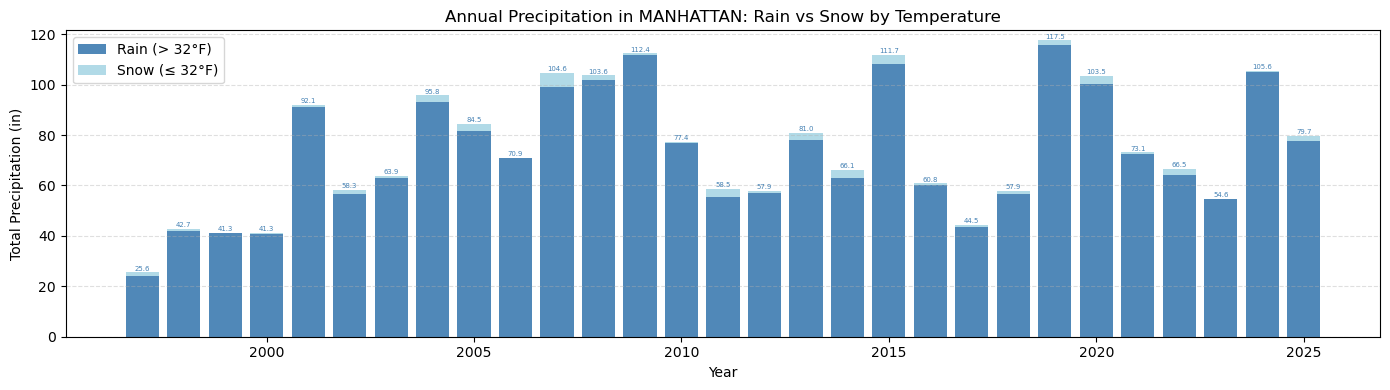

In [10]:
# Split precip by temp at time of observation
rain = location_df[(location_df['year'] < current_year) & (location_df['temp_f'] > 32)]
snow = location_df[(location_df['year'] < current_year) & (location_df['temp_f'] <= 32)]

annual_rain = rain.groupby('year')['precip_inches'].sum()
annual_snow = snow.groupby('year')['precip_inches'].sum()
first_valid_year = annual_rain[annual_rain > 0].index[1]

# Align indices
annual_rain, annual_snow = annual_rain.align(annual_snow, fill_value=0)
annual_rain = annual_rain[annual_rain.index >= first_valid_year]
annual_snow = annual_snow[annual_snow.index >= first_valid_year]
annual_total = annual_rain + annual_snow

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(annual_rain.index, annual_rain.values,
       color='steelblue', alpha=0.95, width=0.8, label='Rain (> 32°F)')
ax.bar(annual_snow.index, annual_snow.values,
       bottom=annual_rain.values,
       color='lightblue', alpha=0.95, width=0.8, label='Snow (≤ 32°F)')

for year, val in annual_total.items():
    ax.text(year, val + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=5, color='steelblue')

ax.set_xlabel('Year')
ax.set_ylabel('Total Precipitation (in)')
ax.set_title(f'Annual Precipitation in {location_df.name[0]}: Rain vs Snow by Temperature')
ax.set_ylim(0, annual_total.max() + 4)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Hourly precipitation

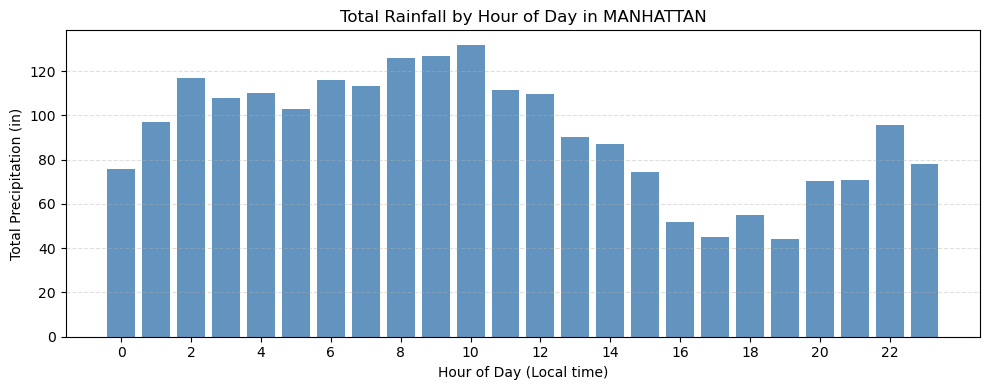

In [11]:
location_df['hour'] = location_df['datetime'].dt.hour
hourly_rain = location_df.groupby('hour')['precip_inches'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_rain.index, hourly_rain.values, color='steelblue', alpha=0.85)
ax.set_xlabel('Hour of Day (Local time)')
ax.set_ylabel('Total Precipitation (in)')
ax.set_title(f'Total Rainfall by Hour of Day in {location_df.name[0]}')
ax.set_xticks(range(0, 24, 2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Annual Relative Humidity

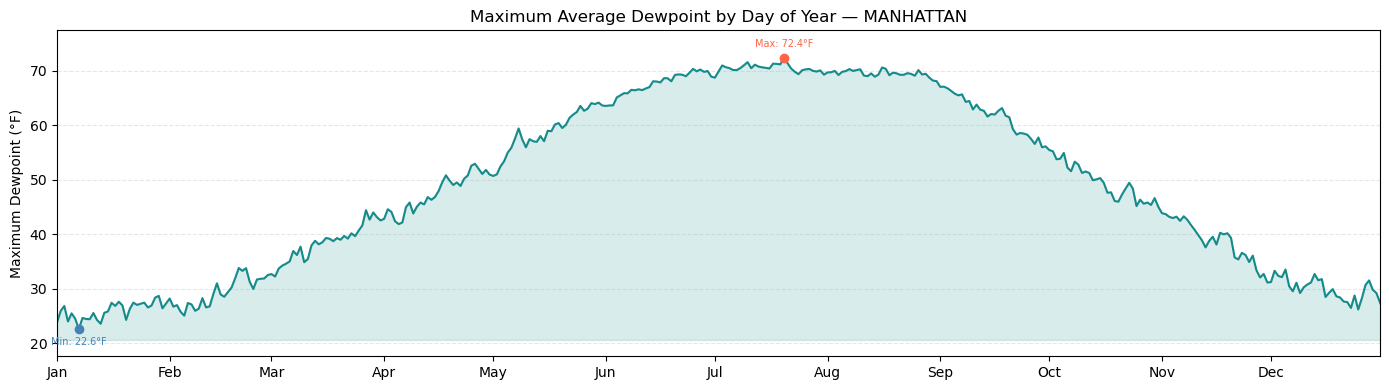

In [12]:
df_new = daily_stats.groupby('doy')['dewmean'].mean()

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_new.index, df_new.values, color='teal', linewidth=1.5, alpha=0.9)
ax.fill_between(df_new.index, df_new.values, df_new.min() - 2,
                alpha=0.15, color='teal')

# Min and max markers
min_doy = df_new.idxmin()
max_doy = df_new.idxmax()

ax.plot(min_doy, df_new.min(), 'o', color='steelblue', markersize=6, zorder=5)
ax.plot(max_doy, df_new.max(), 'o', color='tomato',    markersize=6, zorder=5)

ax.text(min_doy, df_new.min() - 1.5,
        f'Min: {df_new.min():.1f}°F', ha='center', va='top', fontsize=7, color='steelblue')
ax.text(max_doy, df_new.max() + 1.5,
        f'Max: {df_new.max():.1f}°F', ha='center', va='bottom', fontsize=7, color='tomato')

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_names)

ax.set_xlim(1, 365)
ax.set_ylim(df_new.min() - 5, df_new.max() + 5)
ax.set_ylabel('Maximum Dewpoint (°F)')
ax.set_title(f'Maximum Average Dewpoint by Day of Year — {location_df.name[0]}')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Peak wind gusts

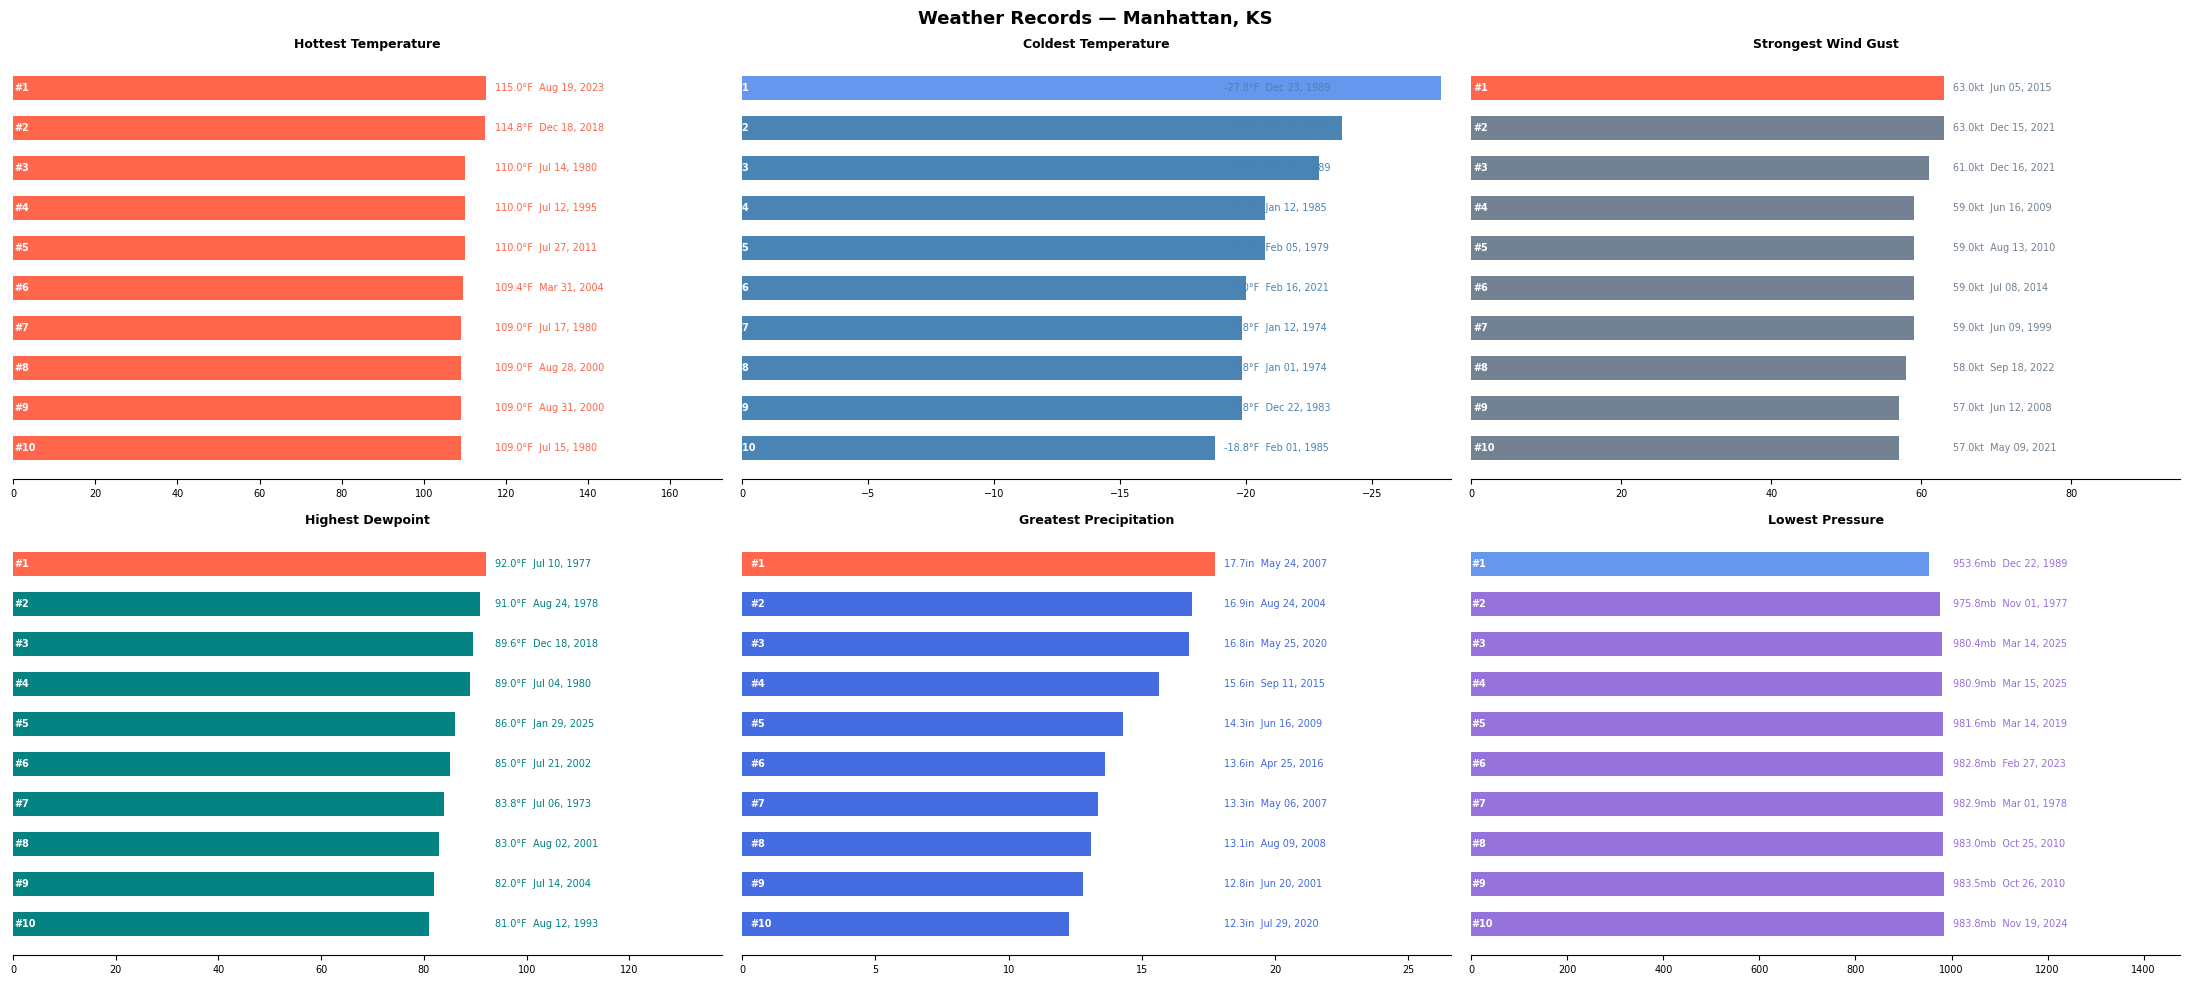

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()

leaderboards = {
    'Hottest Temperature':    ('tmax',         'tomato',    '°F', False),
    'Coldest Temperature':    ('tmin',         'steelblue', '°F', True),
    'Strongest Wind Gust':    ('gustmax',      'slategray', 'kt', False),
    'Highest Dewpoint':       ('dewmean',      'teal',      '°F', False),
    'Greatest Precipitation': ('preciptotal',  'royalblue', 'in', False),
    'Lowest Pressure':        ('mslpmin',      'mediumpurple', 'mb', True),
}

for ax, (title, (col, color, unit, ascending)) in zip(axes, leaderboards.items()):
    top = (
        daily_stats[['date', 'year', col]]
        .dropna(subset=[col])
        .sort_values(col, ascending=ascending)
        .head(10)
        .reset_index(drop=True)
    )
    top.index += 1

    vals = top[col]
    plot_vals = vals

    bars = ax.barh(range(len(top)), plot_vals, color=color, alpha=0.85, height=0.6)
    bars[0].set_facecolor('tomato' if not ascending else 'cornflowerblue')

    if ascending:
        ax.invert_xaxis()

    ax.set_xlim(
        vals.min() - abs(vals.min()) * 0.5,
        vals.max() + abs(vals.max()) * 0.1
    )

    bars = ax.barh(range(len(top)), plot_vals, color=color, alpha=0.85, height=0.6)
    bars[0].set_facecolor('tomato' if not ascending else 'cornflowerblue')

    for i, row in top.iterrows():
        ax.text(0.3, i - 1, f"#{i}", ha='left', va='center',
                fontsize=7, color='white', fontweight='bold')
        ax.text(plot_vals.max() + plot_vals.max() * 0.02, i - 1,
                f"{row[col]:.1f}{unit}  {pd.Timestamp(row['date']).strftime('%b %d, %Y')}",
                va='center', fontsize=7, color=color)

    ax.set_xlim(0, plot_vals.max() * 1.5)
    ax.set_yticks([])
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.invert_yaxis()

fig.suptitle(f'Weather Records — {location_query}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Summary cells, challenge user to expand beyond given info